In [1]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers

os.environ["CUDA_VISIBLE_DEVICES"]= "1"

## Load EffNet : 15AB

In [2]:
model_dir = '/media/tohn/HDD/Model_unlearn/Models_USAI/expV2/R2_balanceclass/on_epoch_end_resume/modelEffNetB5_base_Block5a_se_excite_newdatabalance-R2_epoch20.h5'
print(f"Load Model: {model_dir}")
model = load_model(model_dir)
height = width = model.input_shape[1]
print(height, width)

model.summary()

Load Model: /media/tohn/HDD/Model_unlearn/Models_USAI/expV2/R2_balanceclass/on_epoch_end_resume/modelEffNetB5_base_Block5a_se_excite_newdatabalance-R2_epoch20.h5
456 456
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 456, 456, 3) 0                                            
__________________________________________________________________________________________________
rescaling (Rescaling)           (None, 456, 456, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
normalization (Normalization)   (None, 456, 456, 3)  7           rescaling[0][0]                  
__________________________________________________________________________________________________
stem_conv_pad (ZeroPadd

In [3]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv('/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv('/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [4]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [5]:
print(len(set(dataframe['Sub_class_New'])))
print(set(dataframe['Sub_class_New']))

15
{'AB07', 'AB02', 'AB04', 'AB12', 'AB01', 'AB05', 'AB081', 'AB11', 'AB083', 'AB082', 'AB03', 'Normal', 'AB10', 'AB06', 'AB09'}


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 16
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [7]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])
    print("[INFO]: predict image: ", i+1)

dataframe['category'] = pred_list
dataframe['Prob'] = prob_list

[INFO]: predict image:  1
[INFO]: predict image:  2
[INFO]: predict image:  3
[INFO]: predict image:  4
[INFO]: predict image:  5
[INFO]: predict image:  6
[INFO]: predict image:  7
[INFO]: predict image:  8
[INFO]: predict image:  9
[INFO]: predict image:  10
[INFO]: predict image:  11
[INFO]: predict image:  12
[INFO]: predict image:  13
[INFO]: predict image:  14
[INFO]: predict image:  15
[INFO]: predict image:  16
[INFO]: predict image:  17
[INFO]: predict image:  18
[INFO]: predict image:  19
[INFO]: predict image:  20
[INFO]: predict image:  21
[INFO]: predict image:  22
[INFO]: predict image:  23
[INFO]: predict image:  24
[INFO]: predict image:  25
[INFO]: predict image:  26
[INFO]: predict image:  27
[INFO]: predict image:  28
[INFO]: predict image:  29
[INFO]: predict image:  30
[INFO]: predict image:  31
[INFO]: predict image:  32
[INFO]: predict image:  33
[INFO]: predict image:  34
[INFO]: predict image:  35
[INFO]: predict image:  36
[INFO]: predict image:  37
[INFO]: pr

[INFO]: predict image:  298
[INFO]: predict image:  299
[INFO]: predict image:  300
[INFO]: predict image:  301
[INFO]: predict image:  302
[INFO]: predict image:  303
[INFO]: predict image:  304
[INFO]: predict image:  305
[INFO]: predict image:  306
[INFO]: predict image:  307
[INFO]: predict image:  308
[INFO]: predict image:  309
[INFO]: predict image:  310
[INFO]: predict image:  311
[INFO]: predict image:  312
[INFO]: predict image:  313
[INFO]: predict image:  314
[INFO]: predict image:  315
[INFO]: predict image:  316
[INFO]: predict image:  317
[INFO]: predict image:  318
[INFO]: predict image:  319
[INFO]: predict image:  320
[INFO]: predict image:  321
[INFO]: predict image:  322
[INFO]: predict image:  323
[INFO]: predict image:  324
[INFO]: predict image:  325
[INFO]: predict image:  326
[INFO]: predict image:  327
[INFO]: predict image:  328
[INFO]: predict image:  329
[INFO]: predict image:  330
[INFO]: predict image:  331
[INFO]: predict image:  332
[INFO]: predict imag

[INFO]: predict image:  592
[INFO]: predict image:  593
[INFO]: predict image:  594
[INFO]: predict image:  595
[INFO]: predict image:  596
[INFO]: predict image:  597
[INFO]: predict image:  598
[INFO]: predict image:  599
[INFO]: predict image:  600
[INFO]: predict image:  601
[INFO]: predict image:  602
[INFO]: predict image:  603
[INFO]: predict image:  604
[INFO]: predict image:  605
[INFO]: predict image:  606
[INFO]: predict image:  607
[INFO]: predict image:  608
[INFO]: predict image:  609
[INFO]: predict image:  610
[INFO]: predict image:  611
[INFO]: predict image:  612
[INFO]: predict image:  613
[INFO]: predict image:  614
[INFO]: predict image:  615
[INFO]: predict image:  616
[INFO]: predict image:  617
[INFO]: predict image:  618
[INFO]: predict image:  619
[INFO]: predict image:  620
[INFO]: predict image:  621
[INFO]: predict image:  622
[INFO]: predict image:  623
[INFO]: predict image:  624
[INFO]: predict image:  625
[INFO]: predict image:  626
[INFO]: predict imag

[INFO]: predict image:  886
[INFO]: predict image:  887
[INFO]: predict image:  888
[INFO]: predict image:  889
[INFO]: predict image:  890
[INFO]: predict image:  891
[INFO]: predict image:  892
[INFO]: predict image:  893
[INFO]: predict image:  894
[INFO]: predict image:  895
[INFO]: predict image:  896
[INFO]: predict image:  897
[INFO]: predict image:  898
[INFO]: predict image:  899
[INFO]: predict image:  900
[INFO]: predict image:  901
[INFO]: predict image:  902
[INFO]: predict image:  903
[INFO]: predict image:  904
[INFO]: predict image:  905
[INFO]: predict image:  906
[INFO]: predict image:  907
[INFO]: predict image:  908
[INFO]: predict image:  909
[INFO]: predict image:  910
[INFO]: predict image:  911
[INFO]: predict image:  912
[INFO]: predict image:  913
[INFO]: predict image:  914
[INFO]: predict image:  915
[INFO]: predict image:  916
[INFO]: predict image:  917
[INFO]: predict image:  918
[INFO]: predict image:  919
[INFO]: predict image:  920
[INFO]: predict imag

[INFO]: predict image:  1220
[INFO]: predict image:  1221
[INFO]: predict image:  1222
[INFO]: predict image:  1223
[INFO]: predict image:  1224
[INFO]: predict image:  1225
[INFO]: predict image:  1226
[INFO]: predict image:  1227
[INFO]: predict image:  1228
[INFO]: predict image:  1229
[INFO]: predict image:  1230
[INFO]: predict image:  1231
[INFO]: predict image:  1232
[INFO]: predict image:  1233
[INFO]: predict image:  1234
[INFO]: predict image:  1235
[INFO]: predict image:  1236
[INFO]: predict image:  1237
[INFO]: predict image:  1238
[INFO]: predict image:  1239
[INFO]: predict image:  1240
[INFO]: predict image:  1241
[INFO]: predict image:  1242
[INFO]: predict image:  1243
[INFO]: predict image:  1244
[INFO]: predict image:  1245
[INFO]: predict image:  1246
[INFO]: predict image:  1247
[INFO]: predict image:  1248
[INFO]: predict image:  1249
[INFO]: predict image:  1250
[INFO]: predict image:  1251
[INFO]: predict image:  1252
[INFO]: predict image:  1253
[INFO]: predic

In [8]:
pred_list

['Normal',
 'AB01',
 'AB01',
 'AB02',
 'AB01',
 'Normal',
 'AB02',
 'AB02',
 'AB02',
 'AB04',
 'AB04',
 'AB05',
 'AB05',
 'Normal',
 'Normal',
 'AB09',
 'AB01',
 'Normal',
 'AB082',
 'AB083',
 'AB081',
 'AB03',
 'AB01',
 'AB01',
 'AB02',
 'AB09',
 'AB081',
 'AB082',
 'AB11',
 'AB01',
 'AB01',
 'Normal',
 'AB02',
 'AB082',
 'AB01',
 'AB02',
 'AB02',
 'AB04',
 'AB12',
 'AB04',
 'Normal',
 'AB06',
 'AB07',
 'Normal',
 'AB09',
 'Normal',
 'AB082',
 'AB083',
 'AB083',
 'AB11',
 'AB11',
 'Normal',
 'AB02',
 'AB01',
 'AB02',
 'AB02',
 'AB03',
 'Normal',
 'AB03',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'Normal',
 'AB07',
 'Normal',
 'AB10',
 'Normal',
 'AB082',
 'Normal',
 'Normal',
 'AB11',
 'AB02',
 'AB01',
 'AB01',
 'AB01',
 'AB02',
 'Normal',
 'AB01',
 'AB03',
 'AB03',
 'AB02',
 'AB02',
 'AB03',
 'AB02',
 'AB02',
 'AB03',
 'Normal',
 'Normal',
 'AB082',
 'AB07',
 'AB07',
 'Normal',
 'AB081',
 'Normal',
 'AB05',
 'AB10',
 'AB11',
 'AB02',
 'Normal',
 'AB01',
 'Normal',
 'Nor

In [9]:
prob_list

[0.9999989,
 0.9824081,
 0.999997,
 0.999969,
 0.9938682,
 0.44903058,
 0.9870749,
 0.9484181,
 0.42150432,
 0.9999918,
 1.0,
 1.0,
 1.0,
 0.9979424,
 0.77137333,
 1.0,
 0.9943732,
 0.9999155,
 1.0,
 0.32768267,
 0.9999893,
 0.87992007,
 0.8922874,
 0.91793174,
 0.9988838,
 0.9781788,
 0.84320015,
 0.54222625,
 0.9999956,
 0.998615,
 0.99996126,
 0.9883505,
 0.56240946,
 0.9993216,
 0.99999833,
 0.7369675,
 0.89767706,
 1.0,
 1.0,
 1.0,
 0.9999999,
 0.63064367,
 0.99999964,
 0.99951386,
 0.99985147,
 0.619662,
 1.0,
 0.9999007,
 1.0,
 0.8581967,
 0.9999988,
 0.9604687,
 0.9575377,
 1.0,
 0.99996555,
 0.7463723,
 0.9999044,
 0.9855627,
 0.9984596,
 0.96168464,
 0.9997466,
 0.99998,
 1.0,
 0.9400434,
 0.9674144,
 0.99931204,
 0.894303,
 0.94620126,
 0.8188999,
 0.99999547,
 0.99998105,
 0.94643563,
 0.99760324,
 0.8596952,
 0.99999976,
 0.72367,
 0.93100435,
 0.6009137,
 0.8746065,
 1.0,
 0.99422556,
 0.9993711,
 0.9791133,
 0.9467987,
 1.0,
 0.99980956,
 0.95379275,
 0.99921954,
 0.9995

# Evaluation

In [10]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB07', 'AB02', 'AB04', 'AB12', 'AB01', 'AB05', 'AB081', 'AB03', 'AB083', 'AB082', 'AB11', 'Normal', 'AB10', 'AB06', 'AB09'}
Actual :  15
{'AB07', 'AB02', 'AB04', 'AB12', 'AB01', 'AB05', 'AB081', 'AB11', 'AB083', 'AB082', 'AB03', 'Normal', 'AB10', 'AB06', 'AB09'}


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 79.8780487804878%
              precision    recall  f1-score   support

        AB01       0.52      0.45      0.48        74
        AB02       0.48      0.49      0.48        59
        AB03       0.53      0.42      0.47        19
        AB04       0.61      0.37      0.46        38
        AB05       0.60      0.31      0.41        29
        AB06       0.55      0.57      0.56        21
        AB07       0.79      0.52      0.63        21
       AB081       0.75      0.28      0.41        32
       AB082       0.60      0.54      0.57        28
       AB083       0.40      0.36      0.38        11
        AB09       0.79      0.58      0.67        26
        AB10       0.33      0.10      0.15        10
        AB11       0.90      0.82      0.86        55
        AB12       0.79      0.84      0.82        32
      Normal       0.86      0.95      0.91       857

    accuracy                           0.80      1312
   macro avg       0.63      0.51      0

Text(0.5, 21.5, 'Predicted label')

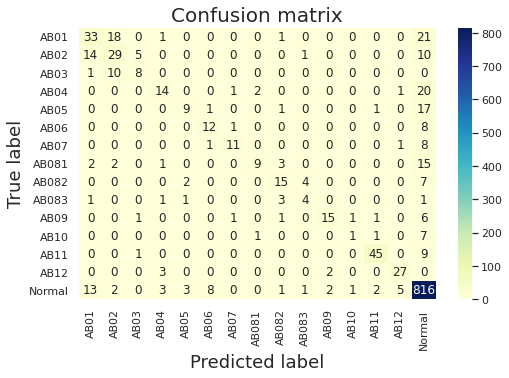

In [12]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [13]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 87.04268292682927%
              precision    recall  f1-score   support

           0       0.86      0.95      0.91       857
           1       0.89      0.72      0.79       455

    accuracy                           0.87      1312
   macro avg       0.88      0.83      0.85      1312
weighted avg       0.87      0.87      0.87      1312



816 41 129 326


Text(48.5, 0.5, 'True label')

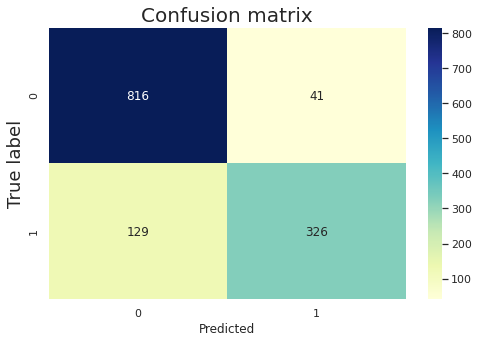

In [14]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [15]:
print(TN, FP, FN, TP)

816 41 129 326


In [16]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB07
classifier accuracy = 0.5238095238095238% 

###### AB02
classifier accuracy = 0.4915254237288136% 

###### AB04
classifier accuracy = 0.3684210526315789% 

###### AB12
classifier accuracy = 0.84375% 

###### AB01
classifier accuracy = 0.44594594594594594% 

###### AB05
classifier accuracy = 0.3103448275862069% 

###### AB081
classifier accuracy = 0.28125% 

###### AB11
classifier accuracy = 0.8181818181818182% 

###### AB083
classifier accuracy = 0.36363636363636365% 

###### AB082
classifier accuracy = 0.5357142857142857% 

###### AB03
classifier accuracy = 0.42105263157894735% 

###### Normal
classifier accuracy = 0.9521586931155193% 

###### AB10
classifier accuracy = 0.1% 

###### AB06
classifier accuracy = 0.5714285714285714% 

###### AB09
classifier accuracy = 0.5769230769230769% 



-----------

-------